# TidyTuesday 2026 - week 7: Agricultural Production Statistics in New Zealand

## Learning to use Jupyter Notebook while exploring and visualizing the New Zealand data. 
---

In [145]:
# --1. load in Week 7 TidyTuesday dataset -------------

#libraries
import pandas as pd
import requests 
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-02-17/dataset.csv')

df = dataset.copy()

### 2. Explore the dataset

In [146]:
#look at a few rows
print(df.head())

   year_ended_june                                    measure     value value_unit  \
0             1935                        Total Area of Farms  17443800     number   
1             1935  Breeding Ewes 2 Tooth and Over put to Ram  17812400     number   
2             1935                                Total Sheep  29077000     number   
3             1935           Total Lambs Marked and/or Tailed  15689000     number   
4             1935                          Wheat (area sown)     91212     number   

       value_label  
0         Hectares  
1  Number of sheep  
2  Number of sheep  
3  Number of sheep  
4         Hectares  


In [147]:
# how many rows and cols
print(df.shape) 

(4739, 5)


In [148]:
# any cols missing values 
print(df.isna().sum())

year_ended_june    0
measure            0
value              0
value_unit         0
value_label        0
dtype: int64


In [149]:
# how many unique agricultural measures are in dataset
print(df['measure'].value_counts())

measure
Total Sheep                         86
Total Lambs Marked and/or Tailed    86
Total Area of Farms                 85
Wheat (yield)                       85
Barley (yield)                      85
                                    ..
Peony                                1
Hydrangea                            1
All other flowers and foliage        1
Perennials (Indoor)                  1
Bedding plants (Indoor)              1
Name: count, Length: 193, dtype: int64


In [150]:
# how many unique agricultural units 
print(df['value_label'].value_counts())

value_label
Hectares                        1760
Number of cattle                 879
Tonnes                           575
Number of sheep                  568
Number of deer                   283
Number of pigs                   194
Square metres                     88
Number of chickens                85
Number of farm holdings           81
Number of poultry                 46
Number of goats                   36
Number of horses                  25
Kilograms                         23
Dozens                            23
Number of alpacas and llamas      17
Cubic metres                      17
Number of livestock               12
Hectared                          11
Number of eggs                     6
Number of alpacas                  5
Number of llamas                   5
Name: count, dtype: int64


### 3. Prepare livestock df and NZ population estimates for plotting 

In [151]:
# Pull out all the total livestock measures to serve as the 
# animal population counts 
livestock_measures = {
    'Total Sheep': 'Sheep',
    'Total Dairy Cattle (including Bobby Calves)': 'Dairy cattle',
    'Total Beef Cattle': 'Beef cattle',
    'Total Deer': 'Deer',
    'Total Pigs': 'Pigs',
    'Total goats': 'Goats',
    'Total poultry': 'Poultry',
}

# filter df for total livestock and make animal column
livestock_df = df[df['measure'].isin(livestock_measures)]
livestock_df['animal'] = df['measure'].map(livestock_measures)

# clean names a bit
livestock_df = livestock_df.rename(columns={
    'year_ended_june':'year',
    'value':'animal_pop'
})
livestock_df = livestock_df[['year','animal', 'animal_pop']]


In [152]:
# read in NZ population estimates spanning 1935 to 2024
# using Wikipedia estimates 

url = 'https://en.wikipedia.org/wiki/Demographics_of_New_Zealand'
headers = {'User-Agent': 'Mozilla/5.0'} # Im a human
response = requests.get(url, headers=headers)

# read the page
soup = BeautifulSoup(response.text, 'lxml')

# find the vital statistics table (it has a column called
# live births 
for table in soup.find_all('table'):
    if 'Live births' in table.get_text():
        target_table = table
        break

# extract rows
rows = []
for row in target_table.find_all('tr'):
    cells = [cell.get_text(strip=True) for cell in row.find_all(['th', 'td'])]
    rows.append(cells)

#keep the first two cols in the table
df_pop = pd.DataFrame(rows[1:], columns=rows[0]).iloc[:,:2]

# rename the columns (the wiki colnames are not optimal)
df_pop = df_pop.rename(columns={
    df_pop.columns[0]: 'year', 
    df_pop.columns[1]: 'human_pop'
})

# year to integer
df_pop['year']=df_pop['year'].astype('int64')

# clean up the year column (remove the [] and commas, make float)
df_pop['human_pop']=(
    df_pop['human_pop']
    .str.replace(r'\[.*?]', '', regex=True)
    .str.replace(',', '', regex=True)
    .astype('int64')
)

In [153]:
# Merge human df to livestock df and calculate the n animal per human ratio
# for each year and livestock type
df_all = livestock_df.merge(df_pop, how='left', on='year')

# ratio
df_all['per_person']=df_all['animal_pop']/df_all['human_pop']

### Plot the data

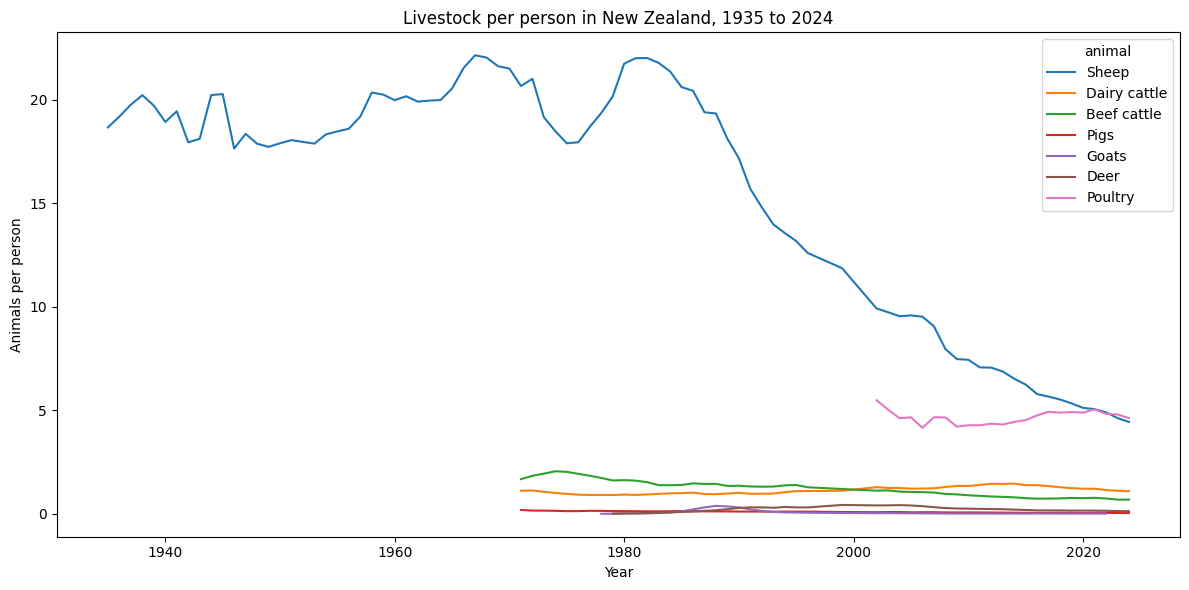

In [155]:
# create plot objects
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_all, x='year', y='per_person', hue='animal', ax=ax)

ax.set_title('Livestock per person in New Zealand, 1935 to 2024')
ax.set_xlabel('Year')
ax.set_ylabel('Animals per person')

plt.tight_layout()
plt.show()